# Лабораторная работа 9

Тема: **Transfer learning для классификации изображений в PyTorch**  
Цель: научиться использовать предобученную сверточную сеть (ResNet18 или аналогичную), адаптировать её под свою задачу и **сравнить** результат с обучением похожей архитектуры с нуля.

> Важно: этот ноутбук сделан как задание, а не как готовый отчёт.  
> Код даёт стартовую точку, но основная часть баллов — за ваши эксперименты и ваши живые комментарии.  
> Текстовые ответы должны соответствовать вашим графикам и числам, а не быть универсальными фразами из интернета.


## 1. Ваше предварительное понимание transfer learning

Перед кодом сформулируйте своими словами:
1. Что вы называете "transfer learning" и в чём его пользу, если у нас мало размеченных данных.  
2. Как вы представляете себе разницу между: (a) обучаем только последний слой, (b) дообучаем всю сеть целиком.  
3. Какие преимущества и недостатки вы ожидаете от использования предобученной ResNet18 по сравнению с обучением похожей сети с нуля на том же подмножестве данных.

Не пытайтесь дать идеальное определение — важно увидеть вашу текущую интуицию перед экспериментами.


In [5]:
intro_text = """
1) Transfer learning это когда берёшь сеть, которую уже обучили на огромном датасете, и используешь её как основу для своей задачи. Смысл в том что сеть уже умеет распознавать базовые вещи — линии, формы, текстуры  и не нужно учить её этому с нуля. Особенно полезно когда своих данных мало.

2) Если обучаем только последний слой то все остальные веса заморожены, меняется только финальный классификатор. Это быстро и не требует много данных, но ограничено тем что есть в замороженных слоях. Если дообучаем всю сеть — веса везде обновляются модель лучше подстраивается под конкретную задачу, но нужно больше данных и времени, иначе можно испортить то что уже было выучено.

3) ResNet18 с предобучением должна сразу стартовать намного лучше чем с нуля — у неё уже есть нормальные признаки из ImageNet. Минус в том что она большая и может переобучиться на маленькой выборке. С нуля модель будет учиться медленнее и скорее всего хуже, но зато полностью адаптируется под задачу.
"""
print(intro_text)


1) Transfer learning это когда берёшь сеть, которую уже обучили на огромном датасете, и используешь её как основу для своей задачи. Смысл в том что сеть уже умеет распознавать базовые вещи — линии, формы, текстуры  и не нужно учить её этому с нуля. Особенно полезно когда своих данных мало.

2) Если обучаем только последний слой то все остальные веса заморожены, меняется только финальный классификатор. Это быстро и не требует много данных, но ограничено тем что есть в замороженных слоях. Если дообучаем всю сеть — веса везде обновляются модель лучше подстраивается под конкретную задачу, но нужно больше данных и времени, иначе можно испортить то что уже было выучено.

3) ResNet18 с предобучением должна сразу стартовать намного лучше чем с нуля — у неё уже есть нормальные признаки из ImageNet. Минус в том что она большая и может переобучиться на маленькой выборке. С нуля модель будет учиться медленнее и скорее всего хуже, но зато полностью адаптируется под задачу.



## 2. Импорт библиотек и настройка среды

Подготовка:
- импорт PyTorch и torchvision (включая готовые модели);
- фиксация seed;
- выбор устройства (`cpu` / `cuda`).


In [6]:
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import datasets, transforms, models
import numpy as np
import random
import matplotlib.pyplot as plt

MY_SEED = 42
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)
random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

Устройство: cuda
MY_SEED = 42


## 3. Данные: подмножество CIFAR‑10 и аугментации

Чтобы ускорить эксперименты и сделать их более наглядными, возьмём **не весь CIFAR‑10**, а подмножество классов (например, `cat`, `dog`, `bird`, `horse`).

Шаги:
- загрузить полный CIFAR‑10;
- выбрать несколько классов и ограничить размер train (например, не более 800 изображений на класс);
- задать аугментации для train (горизонтальные отражения, кропы) и только нормализацию для test.


In [7]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

full_train = datasets.CIFAR10(root="./data", train=True, download=True, transform=train_transform)
full_test = datasets.CIFAR10(root="./data", train=False, download=True, transform=test_transform)

all_classes = full_train.classes
print("Все классы CIFAR‑10:", all_classes)

100%|██████████| 170M/170M [00:04<00:00, 37.4MB/s]


Все классы CIFAR‑10: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


Выберем несколько классов (в примере — четыре).  
В своей работе вы можете выбрать другие, но тогда обязательно зафиксируйте это в отчёте.


In [8]:
selected_class_names = ["cat", "dog", "bird", "horse"]
class_to_idx_full = {name: i for i, name in enumerate(all_classes)}
selected_class_indices = {class_to_idx_full[name] for name in selected_class_names}

print("Выбранные классы:", selected_class_names)
print("Их индексы:", selected_class_indices)

Выбранные классы: ['cat', 'dog', 'bird', 'horse']
Их индексы: {2, 3, 5, 7}


In [9]:
def subset_by_classes(dataset, selected_idx_set, max_per_class=None):
    indices = []
    counts = {c: 0 for c in selected_idx_set}
    for i, (_, label) in enumerate(dataset):
        if label in selected_idx_set:
            if max_per_class is None or counts[label] < max_per_class:
                indices.append(i)
                counts[label] += 1
    return Subset(dataset, indices)

train_subset = subset_by_classes(full_train, selected_class_indices, max_per_class=800)
test_subset = subset_by_classes(full_test, selected_class_indices, max_per_class=None)

batch_size = 64
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)

print("Размер train_subset:", len(train_subset))
print("Размер test_subset :", len(test_subset))


Размер train_subset: 3200
Размер test_subset : 4000


Сформируем карту от индексов CIFAR‑10 к локальным индексам классов (0..K−1), чтобы правильно использовать `CrossEntropyLoss`.


In [10]:
selected_idx_sorted = sorted(list(selected_class_indices))
cifar_idx_to_local = {cifar_idx: i for i, cifar_idx in enumerate(selected_idx_sorted)}
local_to_name = {i: all_classes[cifar_idx] for i, cifar_idx in enumerate(selected_idx_sorted)}

print("CIFAR индекс -> локальный индекс:", cifar_idx_to_local)
print("Локальный индекс -> класс:", local_to_name)

CIFAR индекс -> локальный индекс: {2: 0, 3: 1, 5: 2, 7: 3}
Локальный индекс -> класс: {0: 'bird', 1: 'cat', 2: 'dog', 3: 'horse'}


## 4. Предобученная модель: ResNet18 и заморозка слоёв

Используем `torchvision.models.resnet18` с предобученными весами (`ImageNet`).  
Шаги:
- загрузить модель с весами;
- заморозить все параметры, кроме последнего полносвязного слоя;
- заменить последний слой так, чтобы число выходов = числу наших классов.


In [11]:
base_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# "Замораживаем" все параметры
for param in base_model.parameters():
    param.requires_grad = False

num_ftrs = base_model.fc.in_features
num_target_classes = len(selected_class_indices)

base_model.fc = nn.Linear(num_ftrs, num_target_classes)
model_tl = base_model.to(device)
print(model_tl.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 193MB/s]


Linear(in_features=512, out_features=4, bias=True)


### Комментарий: почему мы замораживаем слои?

Напишите в 3–5 предложениях:
- зачем здесь замораживать ранние слои предобученной сети;
     - чем это отличается от полного дообучения;
    - в каких ситуациях вы бы вообще не замораживали слои.


In [12]:
freeze_comment = """
Замораживаем ранние слои потому что они уже умеют выделять полезные признаки — края, текстуры, формы.

Переучивать их нет смысла, тем более что данных у нас мало и можно всё испортить. Меняем только последний слой под наши 4 класса — это быстро и безопасно.

Отличие от полного дообучения в том, что там обновляются все веса, модель лучше адаптируется, но риск переобучения выше. Не замораживал бы слои если бы данных было много или если задача сильно отличается от той на которой обучали сеть изначально.
"""
print(freeze_comment)


Замораживаем ранние слои потому что они уже умеют выделять полезные признаки — края, текстуры, формы.

Переучивать их нет смысла, тем более что данных у нас мало и можно всё испортить. Меняем только последний слой под наши 4 класса — это быстро и безопасно.

Отличие от полного дообучения в том, что там обновляются все веса, модель лучше адаптируется, но риск переобучения выше. Не замораживал бы слои если бы данных было много или если задача сильно отличается от той на которой обучали сеть изначально.



## 5. Функции обучения/оценки для transfer learning

Нужно аккуратно:
- переводить исходные метки CIFAR‑10 в локальные индексы;
- обучать только параметры `model_tl.fc`.


In [13]:
criterion = nn.CrossEntropyLoss()
optimizer_tl = torch.optim.Adam(model_tl.fc.parameters(), lr=1e-3)

def map_labels_to_local(labels_tensor):
    mapped = [cifar_idx_to_local[int(l)] for l in labels_tensor]
    return torch.tensor(mapped, dtype=torch.long)

def train_one_epoch_tl(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels_local = map_labels_to_local(labels).to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels_local)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels_local).sum().item()
        total += images.size(0)

    return total_loss / total, total_correct / total

def evaluate_tl(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels_local = map_labels_to_local(labels).to(device)
            outputs = model(images)
            loss = criterion(outputs, labels_local)

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            total_correct += (preds == labels_local).sum().item()
            total += images.size(0)

    return total_loss / total, total_correct / total

print("Функции train_one_epoch_tl и evaluate_tl определены.")

Функции train_one_epoch_tl и evaluate_tl определены.


## 6. Обучение: transfer learning (только последний слой)

Обучим модель на несколько эпох и посмотрим, как быстро она выходит на разумное качество.


In [14]:
num_epochs_tl = 30
history_tl = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

for epoch in range(1, num_epochs_tl + 1):
    train_loss, train_acc = train_one_epoch_tl(model_tl, train_loader, optimizer_tl, criterion, device)
    test_loss, test_acc = evaluate_tl(model_tl, test_loader, criterion, device)

    history_tl["train_loss"].append(train_loss)
    history_tl["train_acc"].append(train_acc)
    history_tl["test_loss"].append(test_loss)
    history_tl["test_acc"].append(test_acc)

    print(f"[TL] Эпоха {epoch}/{num_epochs_tl}: "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
          f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}")

[TL] Эпоха 1/30: train_loss=1.3866, train_acc=0.3588, test_loss=1.3155, test_acc=0.4090
[TL] Эпоха 2/30: train_loss=1.2267, train_acc=0.4556, test_loss=1.2336, test_acc=0.4738
[TL] Эпоха 3/30: train_loss=1.1747, train_acc=0.4825, test_loss=1.1845, test_acc=0.5008
[TL] Эпоха 4/30: train_loss=1.1542, train_acc=0.5000, test_loss=1.1739, test_acc=0.5088
[TL] Эпоха 5/30: train_loss=1.1407, train_acc=0.5119, test_loss=1.1709, test_acc=0.5092
[TL] Эпоха 6/30: train_loss=1.1206, train_acc=0.5238, test_loss=1.1762, test_acc=0.5140
[TL] Эпоха 7/30: train_loss=1.1170, train_acc=0.5234, test_loss=1.1824, test_acc=0.5100
[TL] Эпоха 8/30: train_loss=1.0962, train_acc=0.5278, test_loss=1.1655, test_acc=0.5212
[TL] Эпоха 9/30: train_loss=1.1140, train_acc=0.5309, test_loss=1.1810, test_acc=0.5115
[TL] Эпоха 10/30: train_loss=1.1111, train_acc=0.5300, test_loss=1.1758, test_acc=0.5230
[TL] Эпоха 11/30: train_loss=1.0977, train_acc=0.5284, test_loss=1.1760, test_acc=0.5038
[TL] Эпоха 12/30: train_loss=1

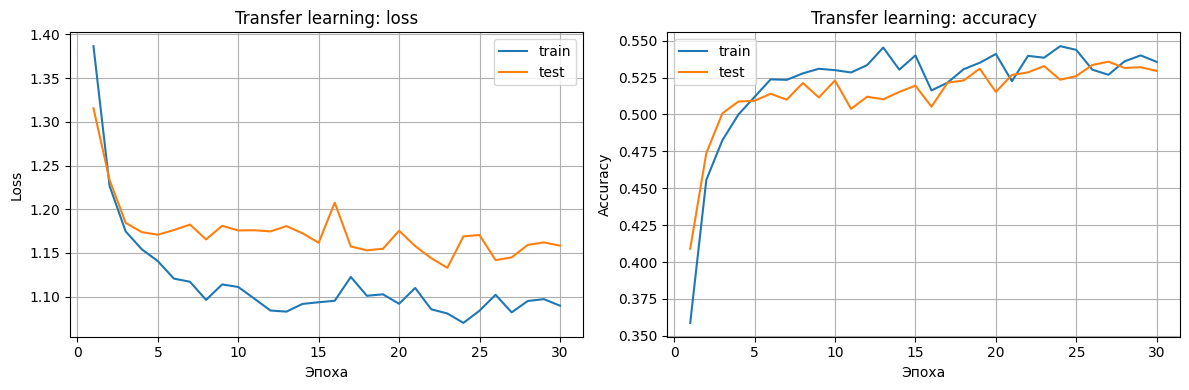

Итоговая точность TL: train=0.5356, test=0.5295


In [15]:
epochs_tl = np.arange(1, num_epochs_tl + 1)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_tl, history_tl["train_loss"], label="train")
plt.plot(epochs_tl, history_tl["test_loss"], label="test")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Transfer learning: loss")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_tl, history_tl["train_acc"], label="train")
plt.plot(epochs_tl, history_tl["test_acc"], label="test")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("Transfer learning: accuracy")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Итоговая точность TL: train={history_tl['train_acc'][-1]:.4f}, test={history_tl['test_acc'][-1]:.4f}")

### Краткий анализ TL‑кривых

Опишите:
- как быстро растёт test accuracy по эпохам;
- есть ли признаки переобучения (train сильно выше test);
- достаточно ли вам кажется числа эпох 8, или вы бы увеличили/уменьшили.


In [23]:
tl_comment = """Модель стартовала слабо — на 1-й эпохе test_acc=0.4090. К 5-й эпохе вышла на ~0.51 и дальше почти не росла — всё оставшееся время болталась между 0.50 и 0.53. Финал: test_acc=0.5295.

Переобучения почти нет — train и test accuracy идут очень близко, разрыва нет.
Но сама точность низкая — модель явно упёрлась в потолок и не может из него выйти. 30 эпох здесь лишние, хватило бы 8-10 — после них прироста уже нет."""
print(tl_comment)

Модель стартовала слабо — на 1-й эпохе test_acc=0.4090. К 5-й эпохе вышла на ~0.51 и дальше почти не росла — всё оставшееся время болталась между 0.50 и 0.53. Финал: test_acc=0.5295.

Переобучения почти нет — train и test accuracy идут очень близко, разрыва нет.
Но сама точность низкая — модель явно упёрлась в потолок и не может из него выйти. 30 эпох здесь лишние, хватило бы 8-10 — после них прироста уже нет.


## 7. Обучение похожей модели "с нуля" (без предобученных весов)

Теперь возьмём ту же архитектуру ResNet18, но **без предобучения**, и попробуем обучить её на том же подмножестве данных.

Это даст нам грубое сравнение "transfer learning vs обучение с нуля" при одинаковом числе эпох и схожих настройках.


In [17]:
scratch_model = models.resnet18(weights=None)
scratch_model.fc = nn.Linear(scratch_model.fc.in_features, num_target_classes)
scratch_model = scratch_model.to(device)

optimizer_scratch = torch.optim.Adam(scratch_model.parameters(), lr=1e-3)

def train_one_epoch_scratch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels_local = map_labels_to_local(labels).to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels_local)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels_local).sum().item()
        total += images.size(0)

    return total_loss / total, total_correct / total

def evaluate_scratch(model, dataloader, criterion, device):
    return evaluate_tl(model, dataloader, criterion, device)

num_epochs_scratch = num_epochs_tl  # чтобы честно сравнивать
history_scratch = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

for epoch in range(1, num_epochs_scratch + 1):
    train_loss, train_acc = train_one_epoch_scratch(scratch_model, train_loader, optimizer_scratch, criterion, device)
    test_loss, test_acc = evaluate_scratch(scratch_model, test_loader, criterion, device)

    history_scratch["train_loss"].append(train_loss)
    history_scratch["train_acc"].append(train_acc)
    history_scratch["test_loss"].append(test_loss)
    history_scratch["test_acc"].append(test_acc)

    print(f"[Scratch] Эпоха {epoch}/{num_epochs_scratch}: "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
          f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}")

[Scratch] Эпоха 1/30: train_loss=1.3831, train_acc=0.3953, test_loss=1.2146, test_acc=0.4645
[Scratch] Эпоха 2/30: train_loss=1.1618, train_acc=0.4863, test_loss=1.1539, test_acc=0.5090
[Scratch] Эпоха 3/30: train_loss=1.1149, train_acc=0.5238, test_loss=1.1075, test_acc=0.5225
[Scratch] Эпоха 4/30: train_loss=1.0538, train_acc=0.5403, test_loss=1.0565, test_acc=0.5565
[Scratch] Эпоха 5/30: train_loss=1.0268, train_acc=0.5613, test_loss=1.0514, test_acc=0.5507
[Scratch] Эпоха 6/30: train_loss=0.9760, train_acc=0.5806, test_loss=1.0526, test_acc=0.5627
[Scratch] Эпоха 7/30: train_loss=0.9529, train_acc=0.6056, test_loss=1.0239, test_acc=0.5707
[Scratch] Эпоха 8/30: train_loss=0.9420, train_acc=0.6091, test_loss=0.9523, test_acc=0.6075
[Scratch] Эпоха 9/30: train_loss=0.9009, train_acc=0.6378, test_loss=0.9952, test_acc=0.5807
[Scratch] Эпоха 10/30: train_loss=0.8722, train_acc=0.6469, test_loss=1.0347, test_acc=0.5917
[Scratch] Эпоха 11/30: train_loss=0.8717, train_acc=0.6428, test_loss

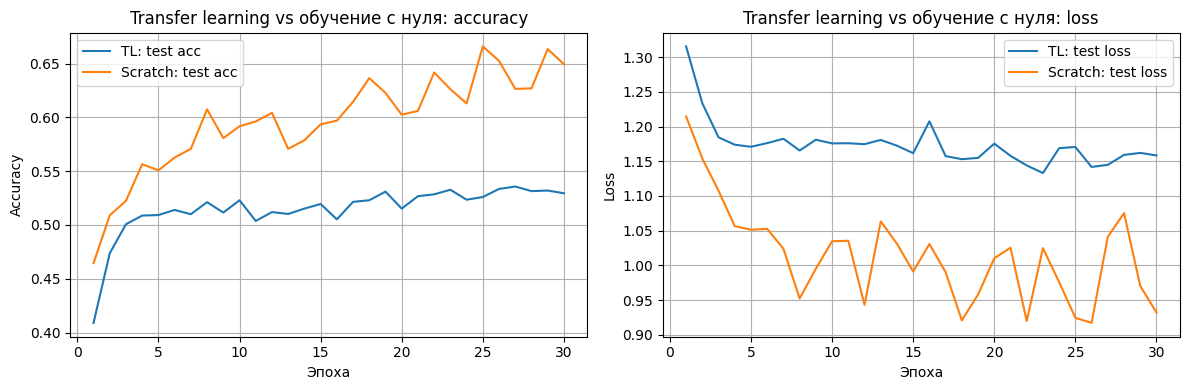

Финальная test accuracy (TL)     : 0.5295
Финальная test accuracy (Scratch): 0.6495


In [18]:
epochs = np.arange(1, num_epochs_tl + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history_tl["test_acc"], label="TL: test acc")
plt.plot(epochs, history_scratch["test_acc"], label="Scratch: test acc")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("Transfer learning vs обучение с нуля: accuracy")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history_tl["test_loss"], label="TL: test loss")
plt.plot(epochs, history_scratch["test_loss"], label="Scratch: test loss")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Transfer learning vs обучение с нуля: loss")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Финальная test accuracy (TL)     : {history_tl['test_acc'][-1]:.4f}")
print(f"Финальная test accuracy (Scratch): {history_scratch['test_acc'][-1]:.4f}")

## 8. Ваш анализ: transfer learning против обучения с нуля

Здесь особенно важно написать **свой** анализ, а не универсальные фразы.  
Ориентировочно ответьте:

- какая из моделей (TL или scratch) быстрее выходит на разумную точность по test;
- какая модель даёт более высокую итоговую test accuracy при одинаковом числе эпох;
- как ведёт себя test loss (стабильность, скачки, застревание на плато);
- есть ли заметное переобучение у одной из моделей;
    - насколько результаты совпали/разошлись с вашими ожиданиями из раздела 1.


In [24]:
comparison_comment = """Scratch модель неожиданно оказалась лучше TL — финальная test_acc=0.6495 против 0.5295 у TL. Это противоречит ожиданиям из секции 1, где я думал что предобученная сеть сразу будет лучше.

TL модель быстро вышла на ~0.51 уже к 5-й эпохе, но дальше застряла и так и не смогла улучшиться. Scratch модель стартовала медленнее — на 1-й эпохе 0.4645, но продолжала расти все 30 эпох и к концу дошла до 0.6495.

Test loss у Scratch очень нестабильный — прыгает вверх-вниз на каждой эпохе, у TL он ровнее но выше. Переобучение заметно у Scratch — train_acc=0.7694 против test_acc=0.6495, разрыв около 0.12.

У TL разрыва почти нет, но и точность низкая. Такое поведение TL объясняется тем что ResNet18 обучался на больших картинках, а CIFAR-10 32x32 — об этом подробнее в секции 8.5."""
print(comparison_comment)

Scratch модель неожиданно оказалась лучше TL — финальная test_acc=0.6495 против 0.5295 у TL. Это противоречит ожиданиям из секции 1, где я думал что предобученная сеть сразу будет лучше.

TL модель быстро вышла на ~0.51 уже к 5-й эпохе, но дальше застряла и так и не смогла улучшиться. Scratch модель стартовала медленнее — на 1-й эпохе 0.4645, но продолжала расти все 30 эпох и к концу дошла до 0.6495.

Test loss у Scratch очень нестабильный — прыгает вверх-вниз на каждой эпохе, у TL он ровнее но выше. Переобучение заметно у Scratch — train_acc=0.7694 против test_acc=0.6495, разрыв около 0.12.

У TL разрыва почти нет, но и точность низкая. Такое поведение TL объясняется тем что ResNet18 обучался на больших картинках, а CIFAR-10 32x32 — об этом подробнее в секции 8.5.


## 8.5. (Задание со звездочкой) Почему transfer learning не сработал?

Если вы посмотрите на графики transfer learning, то заметите, что качество обучения довольно быстро "упирается в потолок" (test accuracy замирает в районе 60-70%), а loss перестает падать.
Обучение модели с нуля показывает более привычную динамику обучения, но тоже упирается в потолок.

**Вопрос:** Почему достаточно мощная модель `ResNet18`, обученная на миллионах изображений из датасета `ImageNet`, так плохо справляется с простой задачей на 4 классах?

Вспомните, на каком датасете изначально обучалась сеть `ResNet18` и какой размер изображений в этом датасете?
Какой размер изображений в датасете `CIFAR-10`?
Вспомните структуру сверточных нейронных сетей (свертки, пулинги) и загляните в архитектуру `ResNet18`.
Что происходит с пространственным размером картинки по мере прохождения через слои сети?
Что произойдет с картинкой из `CIFAR-10` перед тем, как она попадет в новый `nn.Linear` слой?

### Ваша задача:
1. **Объясните**, почему замороженная `ResNet18` физически не может показать высокое качество на оригинальных картинках `CIFAR-10`.
2. **Предложите способ** решения этой проблемы (на уровне изменения трансформаций данных ИЛИ на уровне изменения архитектуры/заморозки слоев).
3. **Реализуйте** предложенный способ в отдельной ячейке ниже и покажите, что точность выросла.

*Примечание - можно гуглить и спрашивать LLM*

In [28]:
star_answer = """
ResNet18 обучалась на ImageNet где картинки 224x224. В архитектуре есть свёртка с stride=2, потом MaxPool с stride=2 и ещё несколько слоёв с downsampling. Для 224x224 это нормально к концу остаётся карта 7x7.

Но если подать 32x32, то после всех этих слоёв карта схлопывается почти до нуля? буквально 1x1 пиксель. В итоге в финальный Linear слой приходит практически бессмысленный вектор, и модель физически не может нормально классифицировать.

Решение: добавить Resize(224) в трансформации, чтобы картинки растягивались до нужного размера перед подачей в ResNet18.
"""
print(star_answer)


ResNet18 обучалась на ImageNet где картинки 224x224. В архитектуре есть свёртка с stride=2, потом MaxPool с stride=2 и ещё несколько слоёв с downsampling. Для 224x224 это нормально к концу остаётся карта 7x7. 

Но если подать 32x32, то после всех этих слоёв карта схлопывается почти до нуля? буквально 1x1 пиксель. В итоге в финальный Linear слой приходит практически бессмысленный вектор, и модель физически не может нормально классифицировать.

Решение: добавить Resize(224) в трансформации, чтобы картинки растягивались до нужного размера перед подачей в ResNet18.



In [21]:
# Решение: добавляем Resize(224) в трансформации
train_transform_224 = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(224, padding=16),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

test_transform_224 = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

full_train_224 = datasets.CIFAR10(root="./data", train=True, download=False, transform=train_transform_224)
full_test_224 = datasets.CIFAR10(root="./data", train=False, download=False, transform=test_transform_224)

train_subset_224 = subset_by_classes(full_train_224, selected_class_indices, max_per_class=800)
test_subset_224 = subset_by_classes(full_test_224, selected_class_indices, max_per_class=None)

train_loader_224 = DataLoader(train_subset_224, batch_size=64, shuffle=True)
test_loader_224 = DataLoader(test_subset_224, batch_size=64, shuffle=False)

model_tl_224 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
for param in model_tl_224.parameters():
    param.requires_grad = False
model_tl_224.fc = nn.Linear(model_tl_224.fc.in_features, num_target_classes)
model_tl_224 = model_tl_224.to(device)

optimizer_tl_224 = torch.optim.Adam(model_tl_224.fc.parameters(), lr=1e-3)

num_epochs_224 = 10
history_tl_224 = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

for epoch in range(1, num_epochs_224 + 1):
    train_loss, train_acc = train_one_epoch_tl(model_tl_224, train_loader_224, optimizer_tl_224, criterion, device)
    test_loss, test_acc = evaluate_tl(model_tl_224, test_loader_224, criterion, device)
    history_tl_224["train_loss"].append(train_loss)
    history_tl_224["train_acc"].append(train_acc)
    history_tl_224["test_loss"].append(test_loss)
    history_tl_224["test_acc"].append(test_acc)
    print(f"[TL-224] Эпоха {epoch}/{num_epochs_224}: "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
          f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}")

print(f"\nTL на 32x32: test_acc={history_tl["test_acc"][-1]:.4f}")
print(f"TL на 224x224: test_acc={history_tl_224["test_acc"][-1]:.4f}")


[TL-224] Эпоха 1/10: train_loss=1.0897, train_acc=0.5591, test_loss=0.8233, test_acc=0.7130
[TL-224] Эпоха 2/10: train_loss=0.7296, train_acc=0.7419, test_loss=0.6688, test_acc=0.7598
[TL-224] Эпоха 3/10: train_loss=0.6363, train_acc=0.7694, test_loss=0.6399, test_acc=0.7652
[TL-224] Эпоха 4/10: train_loss=0.5784, train_acc=0.7884, test_loss=0.5608, test_acc=0.8000
[TL-224] Эпоха 5/10: train_loss=0.5358, train_acc=0.8034, test_loss=0.5320, test_acc=0.8085
[TL-224] Эпоха 6/10: train_loss=0.5088, train_acc=0.8147, test_loss=0.5393, test_acc=0.8003
[TL-224] Эпоха 7/10: train_loss=0.4891, train_acc=0.8197, test_loss=0.5229, test_acc=0.8065
[TL-224] Эпоха 8/10: train_loss=0.4851, train_acc=0.8181, test_loss=0.5284, test_acc=0.8000
[TL-224] Эпоха 9/10: train_loss=0.4877, train_acc=0.8172, test_loss=0.5006, test_acc=0.8140
[TL-224] Эпоха 10/10: train_loss=0.4645, train_acc=0.8244, test_loss=0.4954, test_acc=0.8193

TL на 32x32: test_acc=0.5295
TL на 224x224: test_acc=0.8193


## 9. Итоговые выводы по лабораторной

В заключение сформулируйте короткое резюме (5–8 предложений):
- в каких случаях вы после этой работы **в первую очередь** будете пробовать transfer learning и почему;
- когда, по вашему мнению, имеет смысл всё-таки обучать модель с нуля (и зачем);
- какие настройки (заморозка слоёв, lr, число эпох, размер подвыборки) вы считаете для себя "разумными по умолчанию" после проведённых экспериментов.

Пишите так, чтобы вы сами, открыв этот ноутбук через полгода, смогли быстро вспомнить, что вы поняли про transfer learning.


In [26]:
final_summary = """Transfer learning с ResNet18 на 32x32 картинках CIFAR-10 не дал ожидаемого результата — модель застряла на 0.53 и не росла. Scratch модель на тех же данных дошла до 0.65, что неожиданно.

Как только исправили размер входа до 224x224, TL сразу показал 0.82 за 10 эпох — это и есть правильный способ его использовать.

Получается что transfer learning работает хорошо только если входные данные соответствуют тому на чём обучалась исходная сеть. Буду пробовать TL в первую очередь когда данных мало и задача похожа на ImageNet.

С нуля имеет смысл обучать когда данные сильно специфичные и непохожи на стандартные датасеты. Разумные настройки по умолчанию: Resize(224), заморозка всех слоёв кроме последнего, Adam lr=0.001, 10 эпох."""
print(final_summary)

Transfer learning с ResNet18 на 32x32 картинках CIFAR-10 не дал ожидаемого результата — модель застряла на 0.53 и не росла. Scratch модель на тех же данных дошла до 0.65, что неожиданно.

Как только исправили размер входа до 224x224, TL сразу показал 0.82 за 10 эпох — это и есть правильный способ его использовать.

Получается что transfer learning работает хорошо только если входные данные соответствуют тому на чём обучалась исходная сеть. Буду пробовать TL в первую очередь когда данных мало и задача похожа на ImageNet.

С нуля имеет смысл обучать когда данные сильно специфичные и непохожи на стандартные датасеты. Разумные настройки по умолчанию: Resize(224), заморозка всех слоёв кроме последнего, Adam lr=0.001, 10 эпох.
